In [11]:
# ==========================================================
# Import Libraries
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Load Feature Engineered Data
# ==========================================================

processed_dir = Path("data/processed")

customer_fe = pd.read_csv(
    processed_dir / "customer_fe.csv"
)

future_customer_fe = pd.read_csv(
    processed_dir / "future_customer_fe.csv"
)

# Convert date column
customer_fe["date"] = pd.to_datetime(customer_fe["date"])
future_customer_fe["date"] = pd.to_datetime(
    future_customer_fe["date"]
)

print("=" * 60)
print("FEATURE DATA LOADED")
print("=" * 60)

print(f"Training : {customer_fe.shape}")
print(f"Future   : {future_customer_fe.shape}")

# ==========================================================
# Prepare Modelling Dataset
# ==========================================================

target = "customers"

drop_columns = [
    "customers",
    "sales",
    "date",
    "store_id"

]

feature_columns = [

    col

    for col in customer_fe.columns

    if col not in drop_columns

]

print("=" * 60)
print("FEATURE PREPARATION")
print("=" * 60)

print(f"Target Variable : {target}")
print(f"Number of Features : {len(feature_columns)}")

# ==========================================================
# Train / Validation Split
# ==========================================================

forecast_horizon = 42

cutoff_date = (

        customer_fe["date"].max()

        - pd.Timedelta(days=forecast_horizon - 1)

)

train_df = customer_fe[
    customer_fe["date"] < cutoff_date
    ].copy()

valid_df = customer_fe[
    customer_fe["date"] >= cutoff_date
    ].copy()

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Training observations :", len(train_df))
print("Validation observations:", len(valid_df))

print("\nTraining Period")
print(
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print("\nValidation Period")
print(
    valid_df["date"].min(),
    "to",
    valid_df["date"].max()
)

FEATURE DATA LOADED
Training : (624624, 49)
Future   : (40560, 49)
FEATURE PREPARATION
Target Variable : customers
Number of Features : 45
TRAIN / VALIDATION SPLIT
Training observations : 596232
Validation observations: 28392

Training Period
2013-01-07 00:00:00 to 2015-06-07 00:00:00

Validation Period
2015-06-08 00:00:00 to 2015-07-19 00:00:00


In [12]:
# ==========================================================
# Check Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES BEFORE MODEL")
print("=" * 60)

print("\nTraining Data")
print(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValidation Data")
print(
    valid_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nFuture Data")
print(
    future_customer_fe.isna()
    .sum()
    .sort_values(ascending=False)
)

# ==========================================================
# Remove Missing Values
# ==========================================================

rows_before = len(train_df)

train_df = train_df.dropna().reset_index(drop=True)

rows_after = len(train_df)

print("=" * 60)
print("REMOVE MISSING VALUES")
print("=" * 60)

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

# ==========================================================
# Prepare Model Inputs
# ==========================================================

target = "customers"

drop_columns = [
    "customers",
    "date",
    "store_id"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_columns)
y_valid = valid_df[target]

print("=" * 60)
print("MODEL MATRICES")
print("=" * 60)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nX_valid :", X_valid.shape)
print("y_valid :", y_valid.shape)

print("=" * 60)
print("FEATURE DATA TYPES")
print("=" * 60)

print(X_train.dtypes.value_counts())

object_cols = X_train.select_dtypes(include="object").columns.tolist()

print("\nObject columns:")
print(object_cols)

MISSING VALUES BEFORE MODEL

Training Data
customer_rolling_mean_28    18928
customer_lag_28             18928
customer_rolling_std_28     18928
customer_rolling_mean_21    14196
customer_rolling_std_21     14196
customer_lag_21             14196
customer_rolling_std_14      9464
customer_rolling_mean_14     9464
customer_lag_14              9464
promo_mean_14                9464
promo_lag_7                  4732
customer_rolling_std_7       4732
customer_rolling_mean_7      4732
promo_mean_7                 4732
customer_lag_7               4732
customer_lag_1                676
promo_lag_1                   676
assortment_c                    0
state_holiday_b                 0
state_holiday_a                 0
state_holiday_0                 0
store_type_b                    0
assortment_b                    0
store_type_a                    0
store_type_d                    0
store_type_c                    0
promo_weekend                   0
promo_schoolholiday             0
promo

TRAIN GLOBAL RANDOM FOREST
Training completed.
PREDICTION COMPLETED
Prediction length: 28392
CUSTOMER RANDOM FOREST PERFORMANCE
MAE  : 305.44
RMSE : 459.09
MAPE : 32.84%


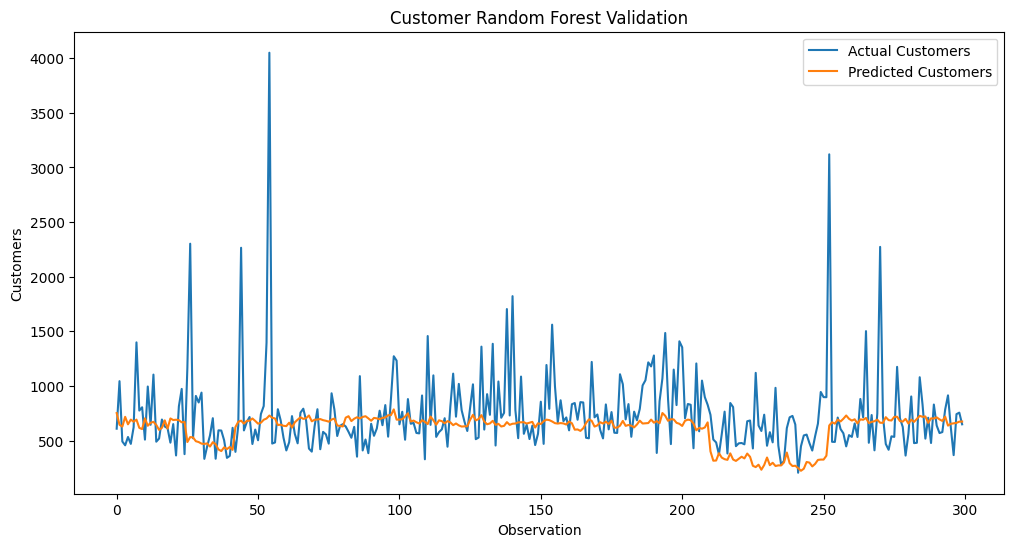

In [13]:
# ==========================================================
# Train Global Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("TRAIN GLOBAL RANDOM FOREST")
print("=" * 60)

rf.fit(X_train, y_train)

print("Training completed.")

# ==========================================================
# Validation Prediction
# ==========================================================

y_pred = rf.predict(X_valid)

print("=" * 60)
print("PREDICTION COMPLETED")
print("=" * 60)

print("Prediction length:", len(y_pred))

# ==========================================================
# Save Validation Results
# ==========================================================

valid_result = valid_df.copy()

valid_result["prediction"] = y_pred

valid_result["abs_error"] = np.abs(
    valid_result["customers"] -
    valid_result["prediction"]
)

valid_result["ape"] = (
                              np.abs(
                                  valid_result["customers"] -
                                  valid_result["prediction"]
                              )
                              /
                              valid_result["customers"]
                      ) * 100

valid_result = valid_result[
    valid_result["customers"] != 0
    ]

# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(
    y_valid,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred
    )
)

mask = y_valid != 0

mape = (
           np.abs(
               (
                       y_valid[mask] -
                       y_pred[mask]
               )
               /
               y_valid[mask]
           ).mean()
       ) * 100

print("=" * 60)
print("CUSTOMER RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# ==========================================================
# Prediction vs Actual
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    y_valid.values[:300],
    label="Actual Customers"
)

plt.plot(
    y_pred[:300],
    label="Predicted Customers"
)

plt.legend()

plt.title("Customer Random Forest Validation")

plt.xlabel("Observation")

plt.ylabel("Customers")

plt.show()

CUSTOMER FEATURE IMPORTANCE
                     Feature  Importance
0       competition_distance    0.169448
1   customer_rolling_mean_28    0.067099
2    customer_rolling_std_28    0.058293
3   customer_rolling_mean_21    0.056768
4   customer_rolling_mean_14    0.055179
5    customer_rolling_std_14    0.051672
6    customer_rolling_std_21    0.051096
7     customer_rolling_std_7    0.045248
8    customer_rolling_mean_7    0.044756
9                      sales    0.040084
10            customer_lag_1    0.035556
11           customer_lag_28    0.034152
12           customer_lag_21    0.033539
13           customer_lag_14    0.033042
14            customer_lag_7    0.032534
15              week_of_year    0.031047
16                      year    0.028850
17              day_of_month    0.024973
18                     month    0.019659
19              promo_mean_7    0.010215
20               day_of_week    0.009653
21                   quarter    0.009290
22              store_type_a 

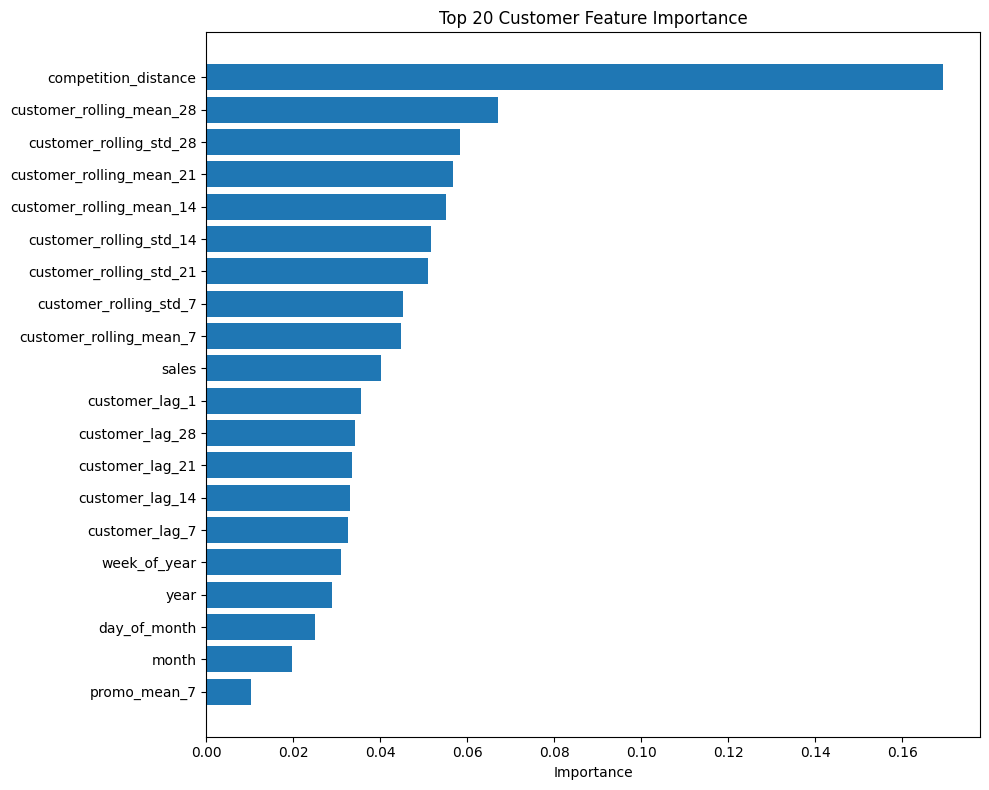

In [14]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",
    ascending=False

).reset_index(drop=True)

print("=" * 60)
print("CUSTOMER FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance)

# ==========================================================
# Plot Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(

    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]

)

plt.title("Top 20 Customer Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [15]:
print(X_train.columns.tolist())

['sales', 'open', 'promo', 'school_holiday', 'competition_distance', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end', 'customer_lag_1', 'customer_lag_7', 'customer_lag_14', 'customer_lag_21', 'customer_lag_28', 'promo_lag_1', 'promo_lag_7', 'customer_rolling_mean_7', 'customer_rolling_std_7', 'customer_rolling_mean_14', 'customer_rolling_std_14', 'customer_rolling_mean_21', 'customer_rolling_std_21', 'customer_rolling_mean_28', 'customer_rolling_std_28', 'promo_mean_7', 'promo_mean_14', 'promo_weekend', 'promo_schoolholiday', 'promo_stateholiday', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']


CUSTOMER RANDOM FOREST HYPERPARAMETER TUNING

Training Model 1/2

Training Model 2/2


CUSTOMER RANDOM FOREST TUNING RESULTS
   n_estimators max_features  min_samples_leaf     CV_MAE     CV_RMSE  \
0           500         sqrt                10  309.21188  459.909776   
1           300         sqrt                10  309.36444  460.042215   

     CV_MAPE  
0  32.928020  
1  32.955317  

Best Parameters
{'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 10}

Best Customer CV MAPE : 32.93%


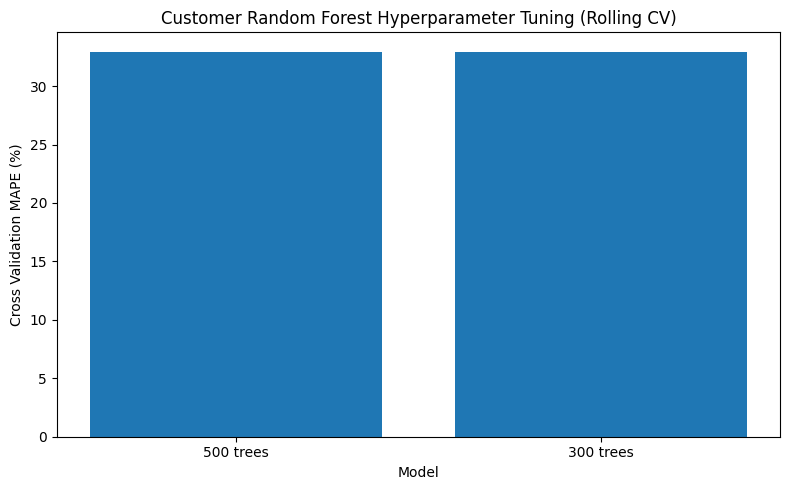

TRAIN FINAL CUSTOMER RANDOM FOREST
Final customer model training completed.
Training observations : 605,696
Number of features    : 46


In [16]:
# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

print("=" * 60)
print("CUSTOMER RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 60)

parameter_list = [

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    }

]

# ==========================================================
# Rolling Forecast Origin Cross Validation
# ==========================================================

n_folds = 3
forecast_horizon = 42

all_dates = np.sort(train_df["date"].unique())

results = []

best_mape = np.inf
best_params = None

for i, params in enumerate(parameter_list, start=1):

    print(f"\nTraining Model {i}/{len(parameter_list)}")

    fold_mae = []
    fold_rmse = []
    fold_mape = []

    for fold in range(n_folds):
        valid_end = len(all_dates) - fold * forecast_horizon
        valid_start = valid_end - forecast_horizon

        valid_dates = all_dates[valid_start:valid_end]
        train_dates = all_dates[:valid_start]

        train_fold = train_df[
            train_df["date"].isin(train_dates)
        ].copy()

        valid_fold = train_df[
            train_df["date"].isin(valid_dates)
        ].copy()

        X_tr = train_fold.drop(columns=drop_columns)
        y_tr = train_fold[target]

        X_va = valid_fold.drop(columns=drop_columns)
        y_va = valid_fold[target]

        rf = RandomForestRegressor(

            random_state=42,
            n_jobs=-1,
            **params

        )

        rf.fit(X_tr, y_tr)

        pred = rf.predict(X_va)

        mae = mean_absolute_error(
            y_va,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_va,
                pred
            )
        )

        mask = y_va != 0

        mape = (
                   np.abs(
                       (
                               y_va[mask] -
                               pred[mask]
                       )
                       /
                       y_va[mask]
                   ).mean()
               ) * 100

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_mape.append(mape)

    avg_mae = np.mean(fold_mae)
    avg_rmse = np.mean(fold_rmse)
    avg_mape = np.mean(fold_mape)

    results.append({

        "n_estimators": params["n_estimators"],
        "max_features": params["max_features"],
        "min_samples_leaf": params["min_samples_leaf"],
        "CV_MAE": avg_mae,
        "CV_RMSE": avg_rmse,
        "CV_MAPE": avg_mape

    })

    if avg_mape < best_mape:
        best_mape = avg_mape
        best_params = params

results = (
    pd.DataFrame(results)
    .sort_values("CV_MAPE")
    .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("CUSTOMER RANDOM FOREST TUNING RESULTS")
print("=" * 60)

print(results)

print("\nBest Parameters")
print(best_params)

print(f"\nBest Customer CV MAPE : {best_mape:.2f}%")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8, 5))

labels = (
        results["n_estimators"].astype(str)
        + " trees"
)

plt.bar(
    labels,
    results["CV_MAPE"]
)

plt.title(
    "Customer Random Forest Hyperparameter Tuning (Rolling CV)"
)

plt.xlabel("Model")

plt.ylabel("Cross Validation MAPE (%)")

plt.tight_layout()

plt.show()

# ==========================================================
# Train Final Customer Random Forest on Full Historical Data
# ==========================================================

print("=" * 60)
print("TRAIN FINAL CUSTOMER RANDOM FOREST")
print("=" * 60)

# ==========================================================
# Use All Historical Data
# ==========================================================

full_df = customer_fe.dropna().copy()

X_full = full_df.drop(columns=drop_columns)

y_full = full_df[target]

# ==========================================================
# Train Final Model
# ==========================================================

final_rf = RandomForestRegressor(

    **best_params,

    random_state=42,

    n_jobs=-1

)

final_rf.fit(

    X_full,

    y_full

)

print("Final customer model training completed.")

print(f"Training observations : {len(full_df):,}")

print(f"Number of features    : {X_full.shape[1]}")

In [19]:
from sklearn.inspection import permutation_importance

# ==========================================================
# Customer Permutation Feature Importance
# ==========================================================

perm_importance = permutation_importance(

    final_rf,

    X_valid,

    y_valid,

    n_repeats=10,

    random_state=42,

    scoring="neg_mean_absolute_error",

    n_jobs=2

)

perm_df = pd.DataFrame({

    "Feature": X_valid.columns,

    "Importance": perm_importance.importances_mean

})

perm_df = (

    perm_df

    .sort_values(

        by="Importance",

        ascending=False

    )

    .reset_index(drop=True)

)

print("=" * 60)
print("CUSTOMER PERMUTATION FEATURE IMPORTANCE")
print("=" * 60)

print(perm_df.head(20))

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(10, 8))

plt.barh(

    perm_df["Feature"][:20][::-1],

    perm_df["Importance"][:20][::-1]

)

plt.title(
    "Top 20 Customer Permutation Feature Importance"
)

plt.xlabel("Permutation Importance")

plt.tight_layout()

plt.show()

C:\Users\setue\anaconda3\envs\bf_perfect\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [18]:
# ==========================================================
# Prepare Future Features
# ==========================================================

future_X = future_customer_fe.drop(
    columns=drop_columns
)

print("=" * 60)
print("CHECK FUTURE FEATURES")
print("=" * 60)

print("Training shape :", X_full.shape)
print("Future shape   :", future_X.shape)

print("\nFeature names identical:")
print(X_full.columns.equals(future_X.columns))

# ==========================================================
# Predict Future Customers
# ==========================================================

future_pred = final_rf.predict(future_X)

future_result = future_customer_fe.copy()

future_result["customer_prediction"] = future_pred

print("=" * 60)
print("FUTURE CUSTOMER PREDICTION")
print("=" * 60)

print(
    future_result[
        [
            "store_id",
            "date",
            "customer_prediction"
        ]
    ].head()
)

print("\nPrediction Summary")

print(
    future_result["customer_prediction"].describe()
)

# ==========================================================
# Save Prediction
# ==========================================================

future_result.to_csv(
    processed_dir / "future_customer_prediction_rf.csv",
    index=False
)

print("Customer prediction file saved successfully.")
future_result[
    [
        "store_id",
        "date",
        "customer_prediction"
    ]
].to_csv(
    processed_dir / "predicted_customers.csv",
    index=False
)

CHECK FUTURE FEATURES
Training shape : (605696, 46)
Future shape   : (40560, 46)

Feature names identical:
True
FUTURE CUSTOMER PREDICTION
   store_id       date  customer_prediction
0         1 2015-09-17           437.370690
1         2 2015-09-17           667.137207
2         3 2015-09-17           673.250164
3         4 2015-09-17           752.277034
4         5 2015-09-17           676.591182

Prediction Summary
count    40560.000000
mean       646.835931
std        104.799266
min        165.326256
25%        601.130245
50%        661.472961
75%        709.423333
max        970.710538
Name: customer_prediction, dtype: float64
Customer prediction file saved successfully.
